# SunSim computational benchmark: photometry

This notebook measures how long every step of a **photometric** simulation takes with a fine grid of the disc (**500 rings**, about 635 000 cells) and the **low resolution** spectra of the tutorial. It runs several simulations (different numbers of active regions, of epochs, with and without a planet) and reports the time of every step and the total.

**Steps that are timed**

| step | what it does |
|---|---|
| `load spectra` | read the low resolution spectra (quiet photosphere, facula, spot) and build the spot spectrum |
| `flux grids` | `flux_grid(..., mode='photometry')` for the three surfaces: flux of one cell of every ring |
| `StarSim init` | grid of the disc (rings and cells), rotation velocity of the cells |
| `grids` | preparation of the grids inside `generate_timeseries` |
| `planets` | positions of the planets at all the epochs |
| `geometry` | positions, radii and visibility of all the regions at all the epochs (NumPy) |
| `timeseries` | the loop over the epochs: filling factors of every cell and flux (one parallel Numba call) |
| `total` | `StarSim init` + `generate_timeseries` of one simulation |

The steps inside `generate_timeseries` are read from `StarSim.timing`.

**Compilation.** The Numba functions are compiled the first time they are called in a new environment, or after the code changed (they are cached on disk afterwards, `cache=True`). That time is measured separately (warm-up), and every simulation is repeated `n_repeats` times; the tables give the median and the minimum of the repeats.

In [1]:
import os
os.environ.setdefault('KMP_WARNINGS', '0')   # before numpy: silences the OpenMP 'omp_set_nested deprecated' info
import time, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numba

from main import StarSim, SOLAR_DIFFERENTIAL_ROTATION
from flux_grid import flux_grid
from active_region import active_region
from planet import planet
from spectrum_utils import black_body

print('machine : %s, %s, %d CPUs' % (platform.platform(), platform.processor(), os.cpu_count()))
print('python %s | numpy %s | numba %s (%d threads)' % (platform.python_version(), np.__version__, numba.__version__, numba.get_num_threads()))

machine : macOS-26.6.2-arm64-arm-64bit, arm, 10 CPUs
python 3.9.23 | numpy 1.26.4 | numba 0.60.0 (10 threads)


## Parameters

The star and the spectra are those of the tutorial. `n_repeats` is the number of times every simulation is run.

In [2]:
N_rings = 500
n_repeats = 3

rotation_period = 24.47                       # [days] at the equator
inclination = 0                               # [rad] equator-on
differential_rotation = SOLAR_DIFFERENTIAL_ROTATION
stellar_radius = 1
T_quiet = 5770                                # [K]
spot_dT = 500                                 # [K]
band = (3800, 8000)                           # [A] box filter of the photometry

path_quiet = '/Users/sophiestucki/Documents/poet/mps/av_solar_ssd_200G_10_mu_angles_PHOENIX_low_res_specint_grid_cleaned.npy'
path_facula = '/Users/sophiestucki/Documents/poet/mps/av_solar_faculae_200G_10_mu_angles_PHOENIX_low_res_specint_grid_cleaned.npy'
path_spot = '/Users/sophiestucki/Downloads/vxdrift_corrected_ssd_spectra/av_solar_ssd_10_mu_angles_PHOENIX_low_res_specint_grid.npy'

## Timer

`timer` records the time of every step in `steps` (and prints it).

In [3]:
steps = {}

class timer:
    """with timer('name'): ... -> steps['name'] = elapsed time [s]."""
    def __init__(self, name):
        self.name = name
    def __enter__(self):
        self.t0 = time.perf_counter()
    def __exit__(self, *args):
        steps[self.name] = time.perf_counter() - self.t0
        print('%-22s %8.3f s' % (self.name, steps[self.name]))

notebook_start = time.perf_counter()

## 1. Spectra and flux grids (done once)

The low resolution spectra are read as in the tutorial; the spot spectrum is the quiet one times the ratio of black bodies at `T_quiet - spot_dT` and `T_quiet`. Then the three photometric grids are built with 500 rings.

In [4]:
with timer('load spectra'):
    flux_quiet_low = np.load(path_quiet, allow_pickle=True).item()
    flux_fc_low = np.load(path_facula, allow_pickle=True).item()
    flux_sp_low = np.load(path_spot, allow_pickle=True).item()
    for mu in flux_sp_low.keys():
        flux_sp_low[mu]['intensity'] *= black_body(flux_sp_low[mu]['wav'], T_quiet - spot_dT) / black_body(flux_sp_low[mu]['wav'], T_quiet)
print('%d mu angles, %d wavelengths' % (len(flux_quiet_low), len(next(iter(flux_quiet_low.values()))['wav'])))

def photometry_grid(flux, typ):
    g = flux_grid(N_rings, flux, typ, None, *band, rotation_period=rotation_period, inclination=inclination,
                  stellar_radius=stellar_radius, stellar_rotation=False, mode='photometry')
    g.built_grid()
    return g

with timer('flux grids'):
    grid_quiet = photometry_grid(flux_quiet_low, 'quiet')
    grid_fc = photometry_grid(flux_fc_low, 'fc')
    grid_sp = photometry_grid(flux_sp_low, 'sp')
grids = dict(flux_grid_qp=grid_quiet.grid, flux_grid_sp=grid_sp.grid, flux_grid_fc=grid_fc.grid)
print('grid of the disc: %d rings, %d cells' % (N_rings, grid_quiet.Ngrids))

load spectra              0.026 s
10 mu angles, 4199 wavelengths
flux grids                0.948 s
grid of the disc: 500 rings, 635357 cells


## 2. The simulations

`run(regions, times, planet)` creates the `StarSim` and runs `generate_timeseries`, and returns the time of every step. The first call (warm-up) includes the compilation of the Numba functions if they are not in the cache yet.

The random regions are spot + facula pairs (a facula of twice the radius around every spot) at random positions, with radii between 2° and 6°, generated with a fixed seed so that every run is the same.

In [5]:
def run(regions, times, planets=None):
    """One photometric simulation: returns (StarSim, {step: time [s]})."""
    t0 = time.perf_counter()
    ss = StarSim(times, N_rings, inclination=inclination, rotation_period=rotation_period,
                 differential_rotation=differential_rotation, stellar_radius=stellar_radius,
                 active_regions_map=regions, planet=planets, mode=['photometry'], **grids)
    t_init = time.perf_counter() - t0
    ss.generate_timeseries()
    timing = {'StarSim init': t_init}
    timing.update({k: v for k, v in ss.timing.items() if k != 'total'})
    timing['total'] = t_init + ss.timing['total']
    return ss, timing


def random_regions(n_pairs, seed=1):
    """n_pairs spot + facula pairs at random positions (fixed seed)."""
    rng = np.random.default_rng(seed)
    regions = []
    for _ in range(n_pairs):
        colat, lon, r = rng.uniform(40, 140), rng.uniform(0, 360), rng.uniform(2, 6)
        regions += [active_region('sp', r, colat, lon), active_region('fc', 2 * r, colat, lon)]
    return regions


one_rotation = lambda n: np.linspace(0, rotation_period, n)
hot_jupiter = planet(planet_period=4, planet_transit_t0=rotation_period / 2, planet_radius=0.1, planet_semi_major_axis=10)
transit_window = np.linspace(rotation_period / 2 - 0.12, rotation_period / 2 + 0.12, 500)

with timer('warm-up (compile)'):
    run([active_region('sp', 10, 90, 180)], one_rotation(10), hot_jupiter)

warm-up (compile)         0.167 s


The simulations: one spot, a spot and a facula, 5, 25 and 100 random spot + facula pairs (10 to 200 regions) over one rotation with 100 epochs, the same with 1000 epochs, and a planet transit alone and over a spot (500 epochs during the transit).

In [6]:
scenarios = {
    '1 spot, 100 epochs':                     ([active_region('sp', 10, 90, 180)], one_rotation(100), None),
    'spot + facula, 100 epochs':              ([active_region('sp', 8, 90, 180), active_region('fc', 14, 90, 180)], one_rotation(100), None),
    '10 regions, 100 epochs':                 (random_regions(5), one_rotation(100), None),
    '50 regions, 100 epochs':                 (random_regions(25), one_rotation(100), None),
    '200 regions, 100 epochs':                (random_regions(100), one_rotation(100), None),
    '1 spot, 1000 epochs':                    ([active_region('sp', 10, 90, 180)], one_rotation(1000), None),
    '50 regions, 1000 epochs':                (random_regions(25), one_rotation(1000), None),
    'planet transit, 500 epochs':             ([], transit_window, hot_jupiter),
    'planet over a spot, 500 epochs':         ([active_region('sp', 10, 90, 180)], transit_window, hot_jupiter),
}

rows, runs = [], {}
for name, (regions, times, planets) in scenarios.items():
    repeats = []
    for _ in range(n_repeats):
        ss, timing = run(regions, times, planets)
        repeats.append(timing)
    runs[name] = ss
    df = pd.DataFrame(repeats)
    row = {'simulation': name, 'regions': len(regions), 'epochs': len(times), 'planet': planets is not None}
    row.update({k: df[k].median() for k in df.columns})
    row['total (min)'] = df['total'].min()
    row['per epoch [ms]'] = 1000 * row['total'] / len(times)
    rows.append(row)
    print('%-34s total %.3f s (median of %d)' % (name, row['total'], n_repeats))

results = pd.DataFrame(rows).set_index('simulation')

1 spot, 100 epochs                 total 0.558 s (median of 3)
spot + facula, 100 epochs          total 0.422 s (median of 3)
10 regions, 100 epochs             total 0.624 s (median of 3)
50 regions, 100 epochs             total 1.800 s (median of 3)
200 regions, 100 epochs            total 6.032 s (median of 3)
1 spot, 1000 epochs                total 2.672 s (median of 3)
50 regions, 1000 epochs            total 20.224 s (median of 3)
planet transit, 500 epochs         total 1.565 s (median of 3)
planet over a spot, 500 epochs     total 3.189 s (median of 3)


## 3. Results

Time of every step [s] (median of the repeats), the minimum of the total, and the total per epoch.

In [7]:
step_cols = [c for c in ['StarSim init', 'grids', 'planets', 'geometry', 'timeseries', 'total', 'total (min)'] if c in results]
pd.options.display.float_format = '{:.4f}'.format
results[['regions', 'epochs', 'planet'] + step_cols + ['per epoch [ms]']]

,regions,epochs,planet,StarSim init,grids,planets,geometry,timeseries,total,total (min),per epoch [ms]
simulation,,,,,,,,,,,
"1 spot, 100 epochs",1,100,False,0.1025,0.0001,0.0000,0.0066,0.3518,0.5577,0.3618,5.5767
"spot + facula, 100 epochs",2,100,False,0.0855,0.0001,0.0000,0.0061,0.3373,0.4224,0.3932,4.2243
"10 regions, 100 epochs",10,100,False,0.0838,0.0001,0.0000,0.0060,0.5466,0.6238,0.6198,6.2384
"50 regions, 100 epochs",50,100,False,0.0913,0.0001,0.0000,0.0094,1.7084,1.7999,1.7867,17.9988
"200 regions, 100 epochs",200,100,False,0.0745,0.0001,0.0000,0.0143,5.9355,6.0316,5.6169,60.3155
"1 spot, 1000 epochs",1,1000,False,0.0803,0.0001,0.0000,0.0058,2.6080,2.6721,2.6149,2.6721
"50 regions, 1000 epochs",50,1000,False,0.0992,0.0001,0.0000,0.0143,20.0810,20.2243,19.8157,20.2243
"planet transit, 500 epochs",0,500,True,0.0918,0.0001,0.0003,0.0046,1.4950,1.5649,1.3868,3.1298
"planet over a spot, 500 epochs",1,500,True,0.1201,0.0001,0.0004,0.0058,3.0372,3.1886,2.6398,6.3772


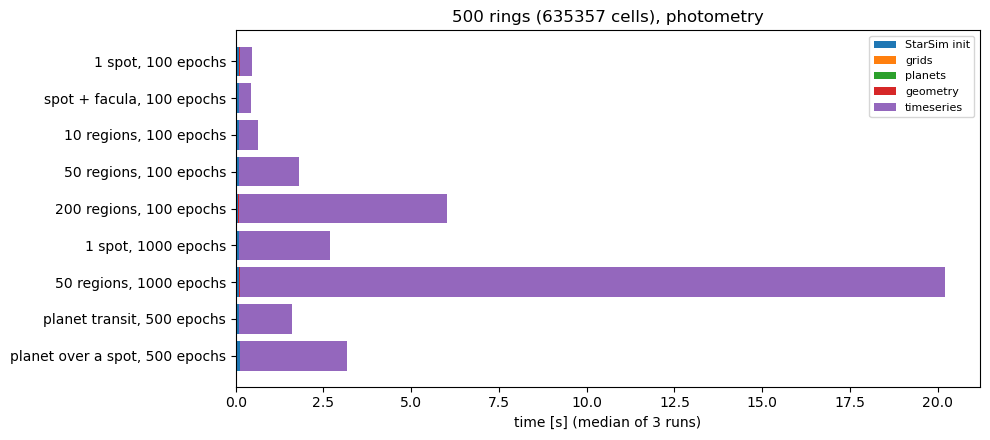

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
parts = [c for c in ['StarSim init', 'grids', 'planets', 'geometry', 'timeseries'] if c in results]
left = np.zeros(len(results))
for part in parts:
    ax.barh(results.index, results[part], left=left, label=part)
    left += results[part].values
ax.invert_yaxis()
ax.set_xlabel('time [s] (median of %d runs)' % n_repeats)
ax.set_title('%d rings (%d cells), photometry' % (N_rings, grid_quiet.Ngrids))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Check of the results.** The light curve of the run with 200 regions and of the planet over a spot, to see that the simulations did what they should.

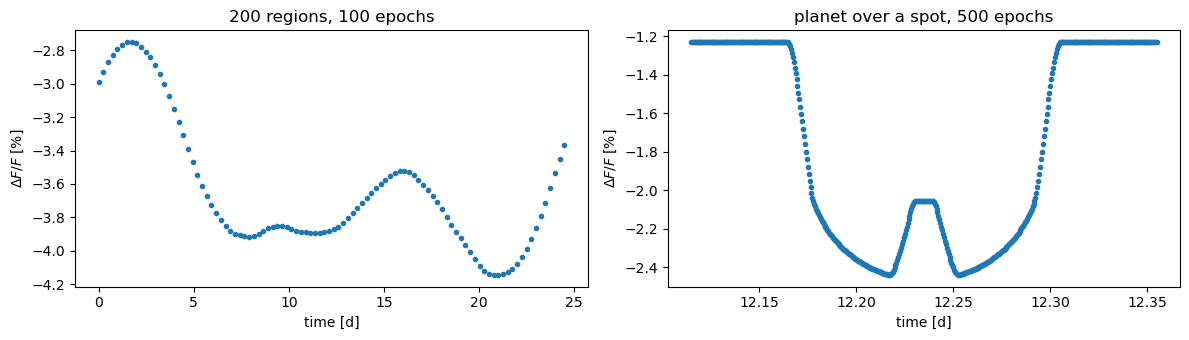

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, name in zip(axes, ['200 regions, 100 epochs', 'planet over a spot, 500 epochs']):
    ss = runs[name]
    ax.plot(ss.obs_times, 100 * (ss.flux_var / grid_quiet.total_brightness - 1), '.')
    ax.set_title(name)
    ax.set_xlabel('time [d]')
    ax.set_ylabel('$\\Delta F / F$ [%]')
plt.tight_layout()
plt.show()

## 4. Scaling

How the time of one simulation grows with the number of regions, of epochs and of rings. Every point is the median of `n_repeats` runs (one rotation, solar differential rotation).

scaling                 126.813 s


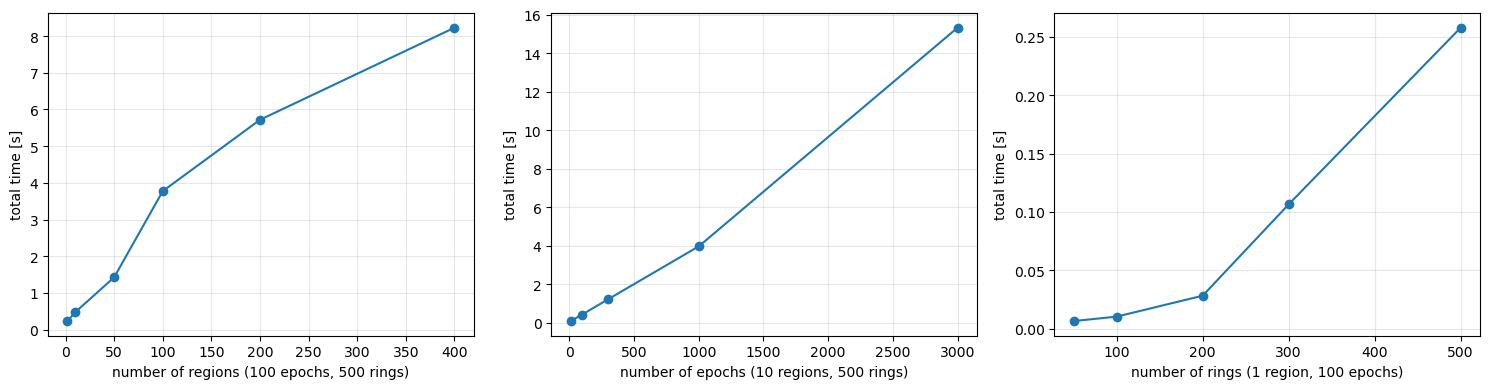

,rings,cells,total [s]
0,50,6240,0.0065
1,100,25211,0.0103
2,200,101351,0.0283
3,300,228420,0.1065
4,500,635347,0.2579


In [13]:
def median_total(regions, times, n_rings=None):
    """Median total time of n_repeats runs (with another number of rings if n_rings is given)."""
    global N_rings, grids
    saved = (N_rings, grids)
    if n_rings is not None and n_rings != N_rings:
        N_rings = n_rings
        grids = dict(flux_grid_qp=photometry_grid(flux_quiet_low, 'quiet').grid,
                     flux_grid_sp=photometry_grid(flux_sp_low, 'sp').grid,
                     flux_grid_fc=photometry_grid(flux_fc_low, 'fc').grid)
    try:
        return np.median([run(regions, times)[1]['total'] for _ in range(n_repeats)])
    finally:
        N_rings, grids = saved

with timer('scaling'):
    n_pairs = [1, 5, 25, 50, 100, 200]
    t_regions = [median_total(random_regions(n), one_rotation(100)) for n in n_pairs]
    n_epochs = [10, 100, 300, 1000, 3000]
    t_epochs = [median_total(random_regions(5), one_rotation(n)) for n in n_epochs]
    n_rings_list = [50, 100, 200, 300, 500]
    t_rings = [median_total([active_region('sp', 10, 90, 180)], one_rotation(100), n) for n in n_rings_list]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot([2 * n for n in n_pairs], t_regions, 'o-')
axes[0].set_xlabel('number of regions (100 epochs, %d rings)' % N_rings)
axes[1].plot(n_epochs, t_epochs, 'o-')
axes[1].set_xlabel('number of epochs (10 regions, %d rings)' % N_rings)
axes[2].plot(n_rings_list, t_rings, 'o-')
axes[2].set_xlabel('number of rings (1 region, 100 epochs)')
for ax in axes:
    ax.set_ylabel('total time [s]')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame({'rings': n_rings_list, 'cells': [int(round(2 * (2 * n - 1)**2 / np.pi)) for n in n_rings_list], 'total [s]': t_rings})

## 5. Total time of the notebook

Time of the steps done once (spectra, grids, compilation), of all the simulations of section 2, of the scaling tests, and the wall-clock time of the whole notebook.

In [11]:
summary = pd.Series({
    'load spectra': steps['load spectra'],
    'flux grids (3 x %d rings)' % N_rings: steps['flux grids'],
    'warm-up (compile)': steps['warm-up (compile)'],
    'simulations of section 2 (sum of the medians)': results['total'].sum(),
    'scaling tests': steps['scaling'],
    'whole notebook (wall clock)': time.perf_counter() - notebook_start,
}, name='time [s]')
summary.to_frame()

,time [s]
load spectra,0.0258
flux grids (3 x 500 rings),0.9482
warm-up (compile),0.1673
simulations of section 2 (sum of the medians),37.0853
scaling tests,113.5006
whole notebook (wall clock),230.1002


In [19]:
# Cost of ONE complete simulation of 1 spot, 100 epochs, 500 rings, from the files to the light curve.
# Without faculae only two surfaces are needed (quiet photosphere and spot): the facula grid can be replaced by the
# quiet one (flux_grid_fc = grid_quiet.grid), so its spectrum does not have to be read nor its grid built.
# 'load spectra' and 'flux grids' were measured for the three surfaces together: their average per surface is used.
n_surfaces = 2                                         # quiet photosphere + spot
one_spot = results.loc['1 spot, 100 epochs']

cost = pd.Series({
    'load spectra (quiet + spot)': steps['load spectra'] / 3 * n_surfaces,
    'flux grids (quiet + spot, %d rings)' % N_rings: steps['flux grids'] / 3 * n_surfaces,
    'StarSim init': one_spot['StarSim init'],
    'geometry (regions)': one_spot['geometry'],
    'timeseries (Numba loop)': one_spot['timeseries'],
    'other steps of generate_timeseries': one_spot['grids'] + one_spot['planets'],
}, name='time [s]')

print('For the case of one spot, 100 epochs, 500 rings the total time is:')
for step, t in cost.items():
    print('   %-40s %8.3f s' % (step, t))
print('   %-40s %8.3f s' % ('TOTAL', cost.sum()))

print('After the first simulations, the following will take:', cost.sum()-cost['load spectra (quiet + spot)']-cost['flux grids (quiet + spot, 500 rings)'])

For the case of one spot, 100 epochs, 500 rings the total time is:
   load spectra (quiet + spot)                 0.017 s
   flux grids (quiet + spot, 500 rings)        0.632 s
   StarSim init                                0.103 s
   geometry (regions)                          0.007 s
   timeseries (Numba loop)                     0.352 s
   other steps of generate_timeseries          0.000 s
   TOTAL                                       1.110 s
After the first simulations, the following will take: 0.4610453749999993
